In [1]:
import pandas as pd

df = pd.read_csv("/Users/armando/Progra/frc/predictor/second_iteration/clean_data.csv")

In [2]:
df.head

<bound method NDFrame.head of       red3_epa  red2_epa  red1_epa  blue3_epa  blue2_epa  blue1_epa  \
0         1498      1790      1772       1498       1790       1772   
1         1498      1790      1772       1498       1790       1772   
2         1532      1427      1453       1532       1427       1453   
3         1790      1414      1416       1790       1414       1416   
4         1769      1472      1607       1769       1472       1607   
...        ...       ...       ...        ...        ...        ...   
8058      1636      1543      1552       1636       1543       1552   
8059      1612      1605      1561       1612       1605       1561   
8060      1672      1643      1510       1672       1643       1510   
8061      1649      1464      1668       1649       1464       1668   
8062      1612      1605      1561       1612       1605       1561   

      red3_total_points  red2_total_points  red1_total_points  \
0                 21.48              65.62          

In [3]:
df['winner'] = ["red" if red_score > blue_score else "blue" for red_score, blue_score in zip(df['red_score'], df['blue_score'])]

In [4]:
df.head()

,red3_epa,red2_epa,red1_epa,blue3_epa,blue2_epa,blue1_epa,red3_total_points,red2_total_points,red1_total_points,blue3_total_points,...,blue1_opr,red3_ccwm,red2_ccwm,red1_ccwm,blue3_ccwm,blue2_ccwm,blue1_ccwm,red_score,blue_score,winner
0,1498,1790,1772,1498,1790,1772,21.48,65.62,62.93,21.48,...,72.195821,-1.699578,69.953685,61.777057,-1.699578,69.953685,61.777057,124,143,blue
1,1498,1790,1772,1498,1790,1772,21.48,65.62,62.93,21.48,...,72.195821,-1.699578,69.953685,61.777057,-1.699578,69.953685,61.777057,144,149,blue
2,1532,1427,1453,1532,1427,1453,26.33,13.02,15.92,26.33,...,16.652785,0.702375,-13.731181,-30.636825,0.702375,-13.731181,-30.636825,129,37,red
3,1790,1414,1416,1790,1414,1416,65.62,11.61,11.81,65.62,...,12.768431,69.953685,-10.160098,-3.674456,69.953685,-10.160098,-3.674456,118,97,red
4,1769,1472,1607,1769,1472,1607,62.48,18.16,37.56,62.48,...,38.539289,39.107122,5.204329,7.925868,39.107122,5.204329,7.925868,67,126,blue


In [5]:
cols_to_drop = ['red_score', 'blue_score']

df = df.drop(columns=cols_to_drop)
df['winner'] = df['winner'].replace({"red": 1, 'blue': 0})

/var/folders/1z/2_97nsjs2dq2vk_ktg2w2zd00000gn/T/ipykernel_77328/776350318.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['winner'] = df['winner'].replace({"red": 1, 'blue': 0})


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8063 entries, 0 to 8062
Data columns (total 79 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   red3_epa              8063 non-null   int64  
 1   red2_epa              8063 non-null   int64  
 2   red1_epa              8063 non-null   int64  
 3   blue3_epa             8063 non-null   int64  
 4   blue2_epa             8063 non-null   int64  
 5   blue1_epa             8063 non-null   int64  
 6   red3_total_points     8063 non-null   float64
 7   red2_total_points     8063 non-null   float64
 8   red1_total_points     8063 non-null   float64
 9   blue3_total_points    8063 non-null   float64
 10  blue2_total_points    8063 non-null   float64
 11  blue1_total_points    8063 non-null   float64
 12  red3_auto_points      8063 non-null   float64
 13  red2_auto_points      8063 non-null   float64
 14  red1_auto_points      8063 non-null   float64
 15  blue3_auto_points    

In [7]:
df['winner'].value_counts()

winner
1    4293
0    3770
Name: count, dtype: int64

In [8]:
from sklearn.model_selection import train_test_split

x = df.drop(columns='winner')
y = df['winner']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=8)


In [9]:
from sklearn.pipeline import Pipeline
from category_encoders import TargetEncoder
from xgboost import XGBClassifier

estimator = [
    ('encoder', TargetEncoder()),
    ('clf', XGBClassifier(random_state=8))
]

pipe = Pipeline(estimator)
pipe

Pipeline(steps=[('encoder', TargetEncoder()),
                ('clf',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [10]:
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

search_space = {
    'clf__max_depth': Integer(2,8),
    'clf__learning_rate': Real(0.001, 1.0, prior='log-uniform'),
    'clf__subsample': Real(0.5, 1.0),
    'clf__colsample_bytree': Real(0.5, 1.0),
    'clf__colsample_bylevel': Real(0.5, 1.0),
    'clf__colsample_bynode' : Real(0.5, 1.0),
    'clf__reg_alpha': Real(0.0, 10.0),
    'clf__reg_lambda': Real(0.0, 10.0),
    'clf__gamma': Real(0.0, 10.0)
}

opt = BayesSearchCV(pipe, search_space, cv=3, n_iter=10, scoring='roc_auc', random_state=8)


In [11]:
opt.fit(x_train, y_train)

BayesSearchCV(cv=3,
              estimator=Pipeline(steps=[('encoder', TargetEncoder()),
                                        ('clf',
                                         XGBClassifier(base_score=None,
                                                       booster=None,
                                                       callbacks=None,
                                                       colsample_bylevel=None,
                                                       colsample_bynode=None,
                                                       colsample_bytree=None,
                                                       device=None,
                                                       early_stopping_rounds=None,
                                                       enable_categorical=False,
                                                       eval_metric=None,
                                                       feature_types=None,
                                                       feature_weights=None,
                                                       gamma=None,
                                                       grow_policy=N...
                             'clf__learning_rate': Real(low=0.001, high=1.0, prior='log-uniform', transform='normalize'),
                             'clf__max_depth': Integer(low=2, high=8, prior='uniform', transform='normalize'),
                             'clf__reg_alpha': Real(low=0.0, high=10.0, prior='uniform', transform='normalize'),
                             'clf__reg_lambda': Real(low=0.0, high=10.0, prior='uniform', transform='normalize'),
                             'clf__subsample': Real(low=0.5, high=1.0, prior='uniform', transform='normalize')})

In [12]:
opt.best_estimator_

Pipeline(steps=[('encoder', TargetEncoder(cols=[])),
                ('clf',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=0.7750018497221565,
                               colsample_bynode=0.5614437441596264,
                               colsample_bytree=0.9126202065825759, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, feature_weights=None,
                               gamm...83, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.4299244814327041, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=6,
                               max_leaves=None, min_child_weight=None,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=None,
                               n_jobs=None, num_parallel_tree=None, ...))])

In [13]:
opt.best_score_

np.float64(0.795191830860024)

In [14]:
opt.score(x_test, y_test)

np.float64(0.7889826242963413)

In [15]:
opt.best_estimator_.steps

[('encoder', TargetEncoder(cols=[])),
 ('clf',
  XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=0.7750018497221565,
                colsample_bynode=0.5614437441596264,
                colsample_bytree=0.9126202065825759, device=None,
                early_stopping_rounds=None, enable_categorical=False,
                eval_metric=None, feature_types=None, feature_weights=None,
                gamma=8.289497472648083, grow_policy=None, importance_type=None,
                interaction_constraints=None, learning_rate=0.4299244814327041,
                max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
                max_delta_step=None, max_depth=6, max_leaves=None,
                min_child_weight=None, missing=nan, monotone_constraints=None,
                multi_strategy=None, n_estimators=None, n_jobs=None,
                num_parallel_tree=None, ...))]

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

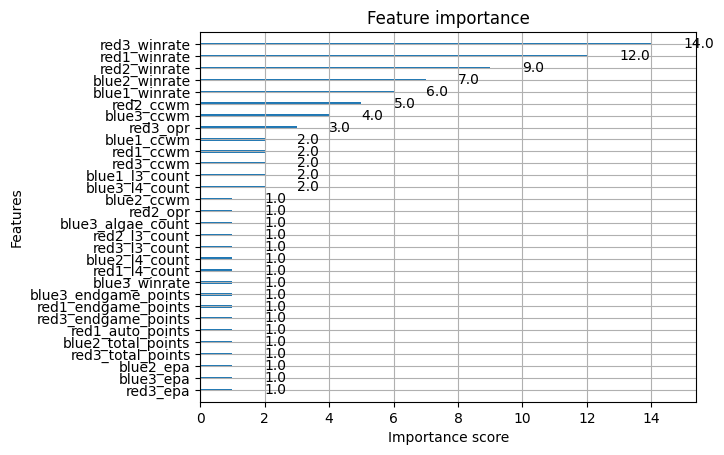

In [16]:
from xgboost import plot_importance

xboost_step = opt.best_estimator_.steps[1]
xboost_model = xboost_step[1]
plot_importance(xboost_model)

In [17]:
def prueba_indice(i: int):
    x_row = x_test.iloc[[i]]
    y_row = y_test.iloc[i]
    print(y_row)
    pred = xboost_model.predict(x_row)[0]
    pred_color = "red" if pred == 1 else "blue"
    real_color = "red" if y_row == 1 else "blue"
    probas = xboost_model.predict_proba(x_row)[0]
    true = "CORRECT!!" if pred_color == real_color else "WRONG"
    
    print("Prediction", true)
    print("Real: ", real_color)
    print(f"--> Predicción: {pred_color} ")
    print(f"--> Probabilidades: blue={probas[0]:.3f}, red={probas[1]:.3f}")

prueba_indice(104)


1
Prediction CORRECT!!
Real:  red
--> Predicción: red 
--> Probabilidades: blue=0.082, red=0.918


/Users/armando/Progra/frc/predictor/.venv/lib/python3.11/site-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


AttributeError: 'Pipeline' object has no attribute 'get_dump'

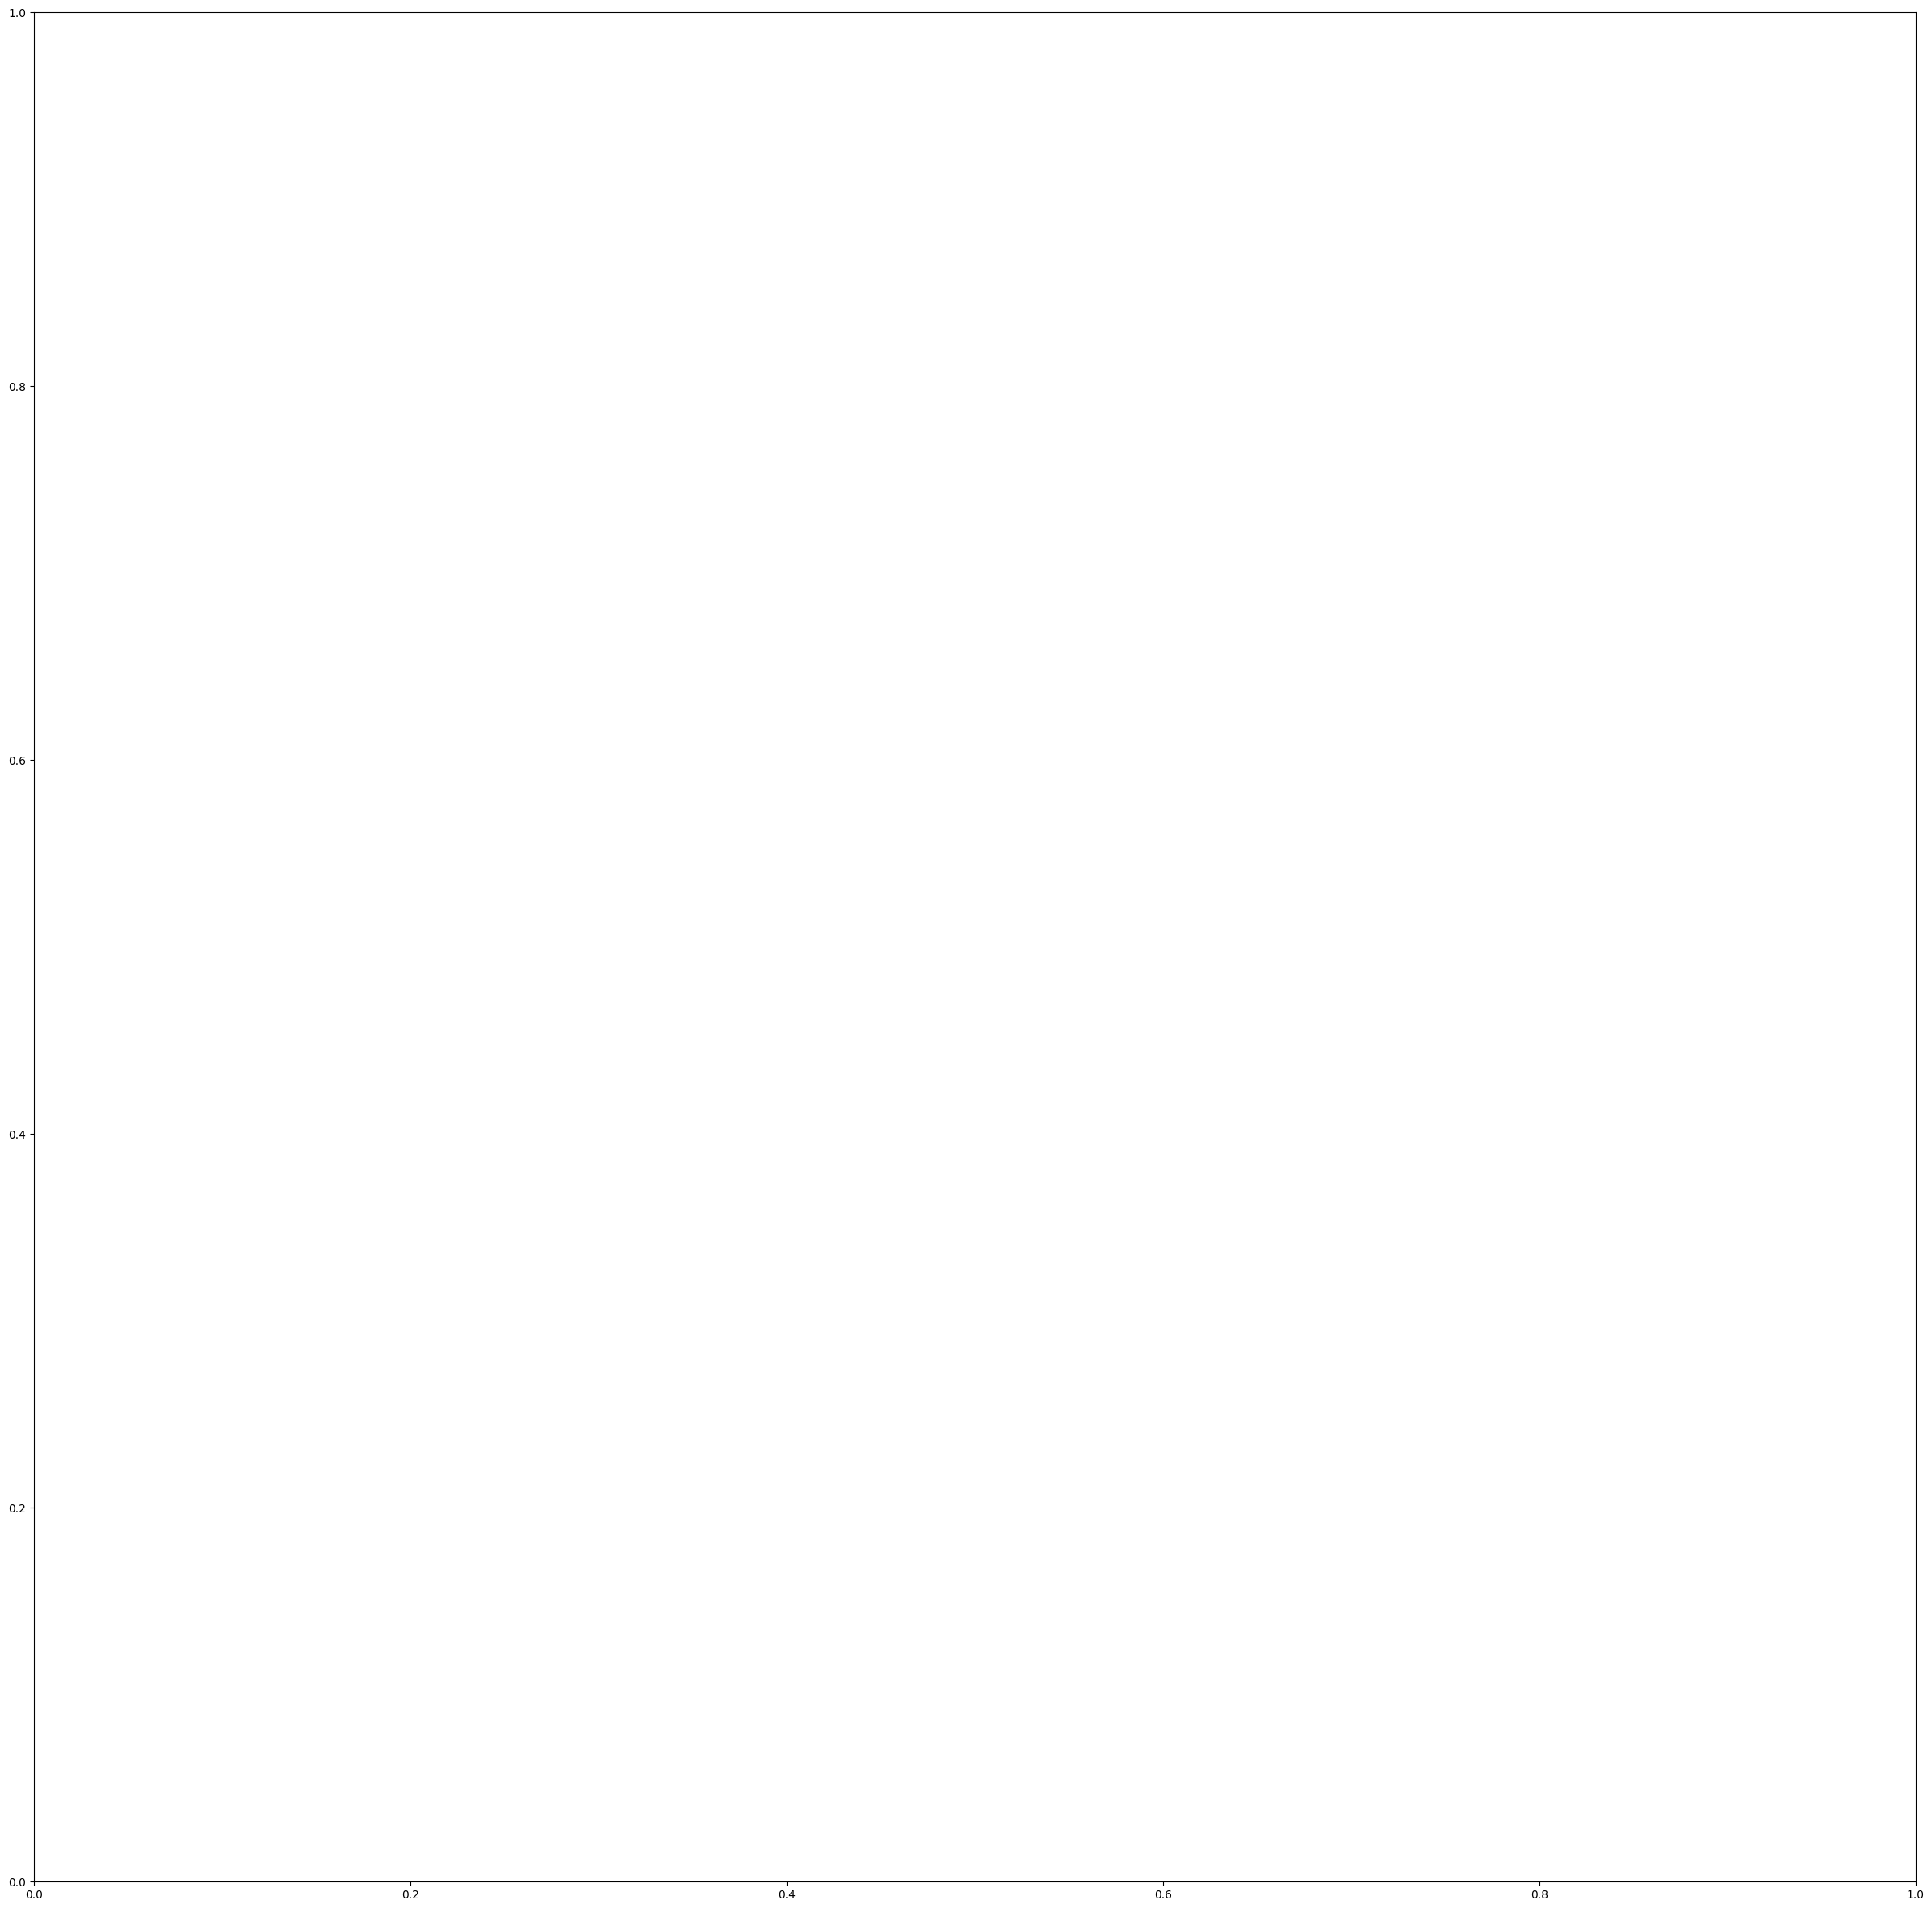

In [19]:
from xgboost import plot_tree

plot_tree(final_red)